# Realizar o pré-processamento dos dados para geração de tiles 3D

In [1]:
import numpy as np
import os
from matplotlib import pyplot as plt
import cv2
import glob
import random
from sklearn.model_selection import train_test_split
import shutil, json
from math import floor

In [2]:
OPTIONS = json.loads(open('../../Task/info.json', 'r').read())
OPTIONS

{'img_size': [128, 128, 128],
 'step': 3,
 'network': 'unet3d_v2',
 'lr': 0.0001,
 'loss': 'dice_focal',
 'batch': 2,
 'scheduler': 'plateau',
 'dropout': 0.1,
 'num_filters': 16}

# Início do Processamento

### Se for treinamento a partir do dado bruto

In [3]:
SIZE_INLINE = OPTIONS.get('img_size')[0]
SIZE_XLINE  = OPTIONS.get('img_size')[1]
SIZE_Z      = OPTIONS.get('img_size')[2]
STEP = OPTIONS.get('step') # parao e 3 (33% dos dados)

print(SIZE_INLINE, SIZE_XLINE, SIZE_Z)
print(STEP)

128 128 128
3


In [4]:
n_classes = 6
reduce_masks = False
cut_block = True
img = False

l_0 = 0
l_1 = 3137
h_0 = 0
h_1 = 1152
w_0 = 0
w_1 = 2240

flag_random_inline = False
mix_train_val = False
flag_chunk_inline = True


norm = True
norm_img = False
stand = False

percent_1_99 = True
percent_5_95 = False
percent_10_90 = False

change_order = False
perc_name    = ''

if percent_1_99:
    perc_name = '1-99'
elif percent_5_95:
    perc_name = '5-95'
else:
    perc_name = '10-90'

include_neg_tile = True
multiple_positive_tiles = False
multiple_value = 5

resize = False

prop_train, prop_val, prop_test = 0.8, 0.1, 0.1


if cut_block:
    seismic = np.load(r'npy/marlim_norm_perc_1-99_cut.npy')

    npy_class_name = 'npy_multiclass_cut.npy'
    masks = np.load(os.path.join(r'npy', npy_class_name))
else:
    seismic = np.load(r'npy\marlim_norm_perc_1-99.npy')
    #seismic = np.transpose(seismic, (0, 2, 1))
    seismic = seismic[l_0:l_1, h_0:h_1, w_0:w_1]

    npy_class_name = 'npy_multiclass.npy'
    masks = np.load(os.path.join(r'npy/',npy_class_name))
    masks = masks[l_0:l_1, h_0:h_1, w_0:w_1]

In [5]:
if reduce_masks:
    masks = np.where(masks < 2,0,masks)
    masks = np.where(masks == 2,1,masks)
    masks = np.where(masks > 2,2,masks)

verificar se os labels estão no formato correto

In [6]:
print(masks.shape)
print(masks[100])
#print(np.unique(masks))
print(seismic.shape)
print(seismic[100])

(3137, 552, 2050)
[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [5 5 5 ... 5 5 5]
 [5 5 5 ... 5 5 5]
 [5 5 5 ... 5 5 5]]
(3137, 552, 2050)
[[0.37290537 0.36444986 0.36089084 ... 0.51014775 0.49493682 0.4852545 ]
 [0.40785295 0.4068946  0.40519926 ... 0.43929744 0.4415203  0.44480518]
 [0.43405852 0.43521324 0.4416801  ... 0.4497263  0.4630243  0.47178409]
 ...
 [0.36904606 0.36989343 0.37306172 ... 0.5090948  0.49288005 0.49380633]
 [0.38072643 0.3858421  0.39209536 ... 0.53808594 0.5163338  0.5142228 ]
 [0.40118158 0.41001314 0.41842085 ... 0.5929423  0.57493937 0.5609261 ]]


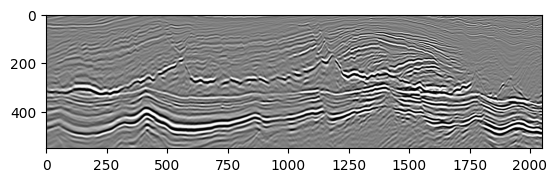

In [7]:
plt.imshow(seismic[37], cmap='gray',vmin=0, vmax=1)

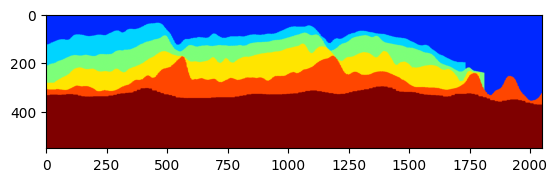

In [8]:
plt.imshow(masks[37], cmap='jet',vmin=-1, vmax=n_classes-1)  # , vmin=-1.5607, vmax=1.5607)

Prename da rede, de acordo com a configuração escolhida do dataset

'Train-80% Val-10% Test-10%_Tile-64_Chunk Inline-64_Percentil 1-99_Normalization_MultiClass_Cut-Block_NoResize-Block'

In [9]:
preprocessing_infos = 'Train-' + str(int(prop_train*100)) + '% '
preprocessing_infos = preprocessing_infos + 'Val-' + str(int(prop_val*100)) + '% '
preprocessing_infos = preprocessing_infos + 'Test-' + str(int(prop_test*100)) + '%' + '_'

if change_order:
    preprocessing_infos = preprocessing_infos + f'Tile-(z={SIZE_Z},inline={SIZE_INLINE},xline={SIZE_XLINE})'+ '_'
else:
    preprocessing_infos = preprocessing_infos + f'Tile-(inline={SIZE_INLINE},z={SIZE_Z},xline={SIZE_XLINE})'+ '_'

if flag_random_inline:
    preprocessing_infos = preprocessing_infos + 'Random-Inline'+ '_'
elif flag_chunk_inline:
    preprocessing_infos = preprocessing_infos + 'Chunk Inline-'+ str(SIZE_XLINE) + '_'
else:
    preprocessing_infos = preprocessing_infos + 'Random-All'+ '_'

preprocessing_infos = preprocessing_infos + 'STEP-' + str(STEP) + '_'

preprocessing_infos = preprocessing_infos + 'Percentil ' + perc_name + '_'
if norm:
    if norm_img:
        preprocessing_infos = preprocessing_infos + 'Normalization-Image' + '_'
    else:
        preprocessing_infos = preprocessing_infos + 'Normalization' + '_'
else:
    if stand:
        preprocessing_infos = preprocessing_infos + 'Standardization' + '_'
    else:
        preprocessing_infos = preprocessing_infos + 'No Norm/Stand' + '_'

preprocessing_infos = preprocessing_infos + 'MultiClass' + '_'
if cut_block:
    preprocessing_infos = preprocessing_infos + 'Cut-Block' + '_'
else:
    preprocessing_infos = preprocessing_infos + 'No Cut-Block' + '_'

print(preprocessing_infos)

Train-80% Val-10% Test-10%_Tile-(inline=128,z=128,xline=128)_Chunk Inline-128_STEP-3_Percentil 1-99_Normalization_MultiClass_Cut-Block_


## Redução em x vezes

In [10]:
import numpy as np
from scipy.ndimage import zoom

if resize:
    factor = 3.5

    # Fatores de redução em cada dimensão
    scale_factors = (1/factor, 1/factor, 1/factor)

    print("Tamanho original:", seismic.shape)
    # Realizar a redução usando zoom da biblioteca scipy.ndimage
    seismic = zoom(seismic, scale_factors, order=1)  # Usando interpolação linear (order=1)
    print("Tamanho reduzido:", seismic.shape)

    print("Tamanho original:", masks.shape)
    # Realizar a redução usando zoom da biblioteca scipy.ndimage
    # Usando interpolação linear (order=1)
    masks = zoom(masks, scale_factors, order=0)
    print("Tamanho reduzido:", masks.shape)
    preprocessing_infos = preprocessing_infos + 'Resz-' + str(factor) + '_'
else:
    preprocessing_infos = preprocessing_infos + 'No Resize-Block'

#shapes = masks.shape
print(preprocessing_infos)


Train-80% Val-10% Test-10%_Tile-(inline=128,z=128,xline=128)_Chunk Inline-128_STEP-3_Percentil 1-99_Normalization_MultiClass_Cut-Block_No Resize-Block


Sanity check

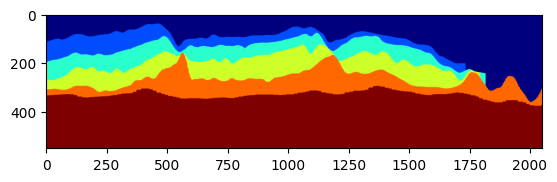

In [11]:
plt.imshow(masks[20], cmap='jet')  # , vmin=-1.5607, vmax=1.5607)

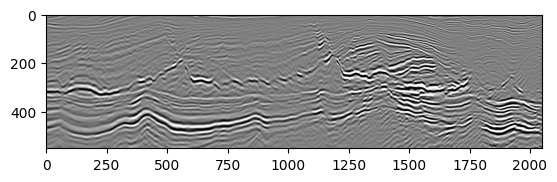

In [12]:
if img:
    plt.imshow(seismic[20],cmap='gray', vmin=0, vmax=255)
else:
    plt.imshow(seismic[20],cmap='gray', vmin=0, vmax=1.0)

In [13]:
if flag_chunk_inline:
    def extend_block_continuous(block, inline_size=128,z_size=16,xline_size=128):
        print('extend_block_continuous')
        # Tamanho original do bloco
        original_shape = block.shape
        extended_shape = [0,0,0]

        # Dimensões estendidas (sempre arredondando para cima)
        for i in range(3):
            if i == 0:
                extended_shape[0] = int(np.ceil(original_shape[i] / inline_size)) * inline_size
            if i == 1:
                extended_shape[1] = int(np.ceil(original_shape[i] / z_size)) * z_size
            if i == 2:
                extended_shape[2] = int(np.ceil(original_shape[i] / xline_size)) * xline_size

        # Criar bloco estendido com zeros
        extended_block = np.zeros(extended_shape, dtype=block.dtype)

        # Copiar o bloco original para o bloco estendido
        extended_block[:original_shape[0], :original_shape[1], :original_shape[2]] = block

        # Preencher as bordas para garantir continuidade
        for dim in range(3):
            excess = extended_shape[dim] - original_shape[dim]
            
            if dim == 0 and excess > 0:
                extended_block[-inline_size:, :, :] = extended_block[original_shape[dim]-inline_size:original_shape[dim], :, :]
            elif dim == 1 and excess > 0:
                extended_block[:, -z_size:, :] = extended_block[:, original_shape[dim]-z_size:original_shape[dim], :]
            elif dim == 2 and excess > 0:
                extended_block[:, :, -xline_size:] = extended_block[:, :, original_shape[dim]-xline_size:original_shape[dim]]
        
        return extended_block
        
    def split_into_inline_blocks(block, tile_size=128):
        print('split_into_inline_blocks')
        patches = []
        for i in range(0, block.shape[0], tile_size):
                    patches.append(block[i:i+tile_size, :,:])
        return np.array(patches)

    print("Original seismic shape:", seismic.shape)
    ext_seismic = extend_block_continuous(seismic, inline_size=SIZE_INLINE,z_size=SIZE_Z,xline_size=SIZE_XLINE)
    print("Extended seismic shape:", ext_seismic.shape)
    del seismic

    seismic_il_blocks = split_into_inline_blocks(ext_seismic,tile_size=SIZE_INLINE)
    print("Seismic patches shape:", seismic_il_blocks.shape)
    del ext_seismic

    new_seismic_il_blocks = []
    new_seismic_il_blocks = [seismic_il_blocks[i] for i in range(0,seismic_il_blocks.shape[0],STEP)]
    seismic_il_blocks = np.array(new_seismic_il_blocks)
    del new_seismic_il_blocks

    print("Original masks shape:", masks.shape)
    ext_masks = extend_block_continuous(masks, inline_size=SIZE_INLINE,z_size=SIZE_Z,xline_size=SIZE_XLINE)
    ext_masks_cpy = np.copy(ext_masks)
    print("Extended masks shape:", ext_masks.shape)
    del masks

    masks_il_blocks = split_into_inline_blocks(ext_masks,tile_size=SIZE_INLINE)
    print("Mask patches shape:", masks_il_blocks.shape)
    del ext_masks

    new_masks_il_blocks = []
    new_masks_il_blocks = [masks_il_blocks[i] for i in range(0,masks_il_blocks.shape[0],STEP)]
    masks_il_blocks = np.array(new_masks_il_blocks)
    del new_masks_il_blocks

Original seismic shape: (3137, 552, 2050)
extend_block_continuous
Extended seismic shape: (3200, 640, 2176)
split_into_inline_blocks
Seismic patches shape: (25, 128, 640, 2176)
Original masks shape: (3137, 552, 2050)
extend_block_continuous
Extended masks shape: (3200, 640, 2176)
split_into_inline_blocks
Mask patches shape: (25, 128, 640, 2176)


In [14]:
if flag_chunk_inline:      
    X_train, X_val_test, y_train, y_val_test = train_test_split(seismic_il_blocks, masks_il_blocks, test_size = 1-prop_train, random_state = 15)  #original random_state = 10
    X_val, X_test, y_val, y_test = train_test_split(X_val_test, y_val_test, test_size = 0.5, random_state = 0)

    print("X_train patches shape:", X_train.shape)
    print("y_train patches shape:", y_train.shape)
    print("X_val patches shape:", X_val.shape)
    print("y_val patches shape:", y_val.shape)
    print("X_test patches shape:", X_test.shape)
    print("y_test patches shape:", y_test.shape)

    del seismic_il_blocks
    del masks_il_blocks

X_train patches shape: (7, 128, 640, 2176)
y_train patches shape: (7, 128, 640, 2176)
X_val patches shape: (1, 128, 640, 2176)
y_val patches shape: (1, 128, 640, 2176)
X_test patches shape: (1, 128, 640, 2176)
y_test patches shape: (1, 128, 640, 2176)


In [15]:
if flag_chunk_inline:  
    # Para dividir o bloco extendido em patches 3D:
    def split_into_patches(block, inline_size=128,z_size=16,xline_size=128):
        patches = []
        for l in range(block.shape[0]):
            for i in range(0, block[l].shape[0], inline_size):
                for j in range(0, block[l].shape[1], z_size):
                    for k in range(0, block[l].shape[2], xline_size):
                        patches.append(block[l,i:i+inline_size, j:j+z_size, k:k+xline_size])
        return np.array(patches)

    X_train = split_into_patches(X_train,inline_size=SIZE_INLINE,z_size=SIZE_Z,xline_size=SIZE_XLINE)
    #X_train = np.transpose(X_train, (0,2,3,1))
    print("X_train patches shape:", X_train.shape)
    y_train = split_into_patches(y_train,inline_size=SIZE_INLINE,z_size=SIZE_Z,xline_size=SIZE_XLINE)
    #y_train = np.transpose(y_train, (0,2,3,1))
    print("y_train patches shape:", y_train.shape)

    X_val = split_into_patches(X_val,inline_size=SIZE_INLINE,z_size=SIZE_Z,xline_size=SIZE_XLINE)
    #X_val = np.transpose(X_val, (0,2,3,1))
    print("X_val patches shape:", X_val.shape)
    y_val = split_into_patches(y_val,inline_size=SIZE_INLINE,z_size=SIZE_Z,xline_size=SIZE_XLINE)
    #y_val = np.transpose(y_val, (0,2,3,1))
    print("y_val patches shape:", y_val.shape)

    X_test = split_into_patches(X_test,inline_size=SIZE_INLINE,z_size=SIZE_Z,xline_size=SIZE_XLINE)
    #X_test = np.transpose(X_test, (0,2,3,1))
    print("X_test patches shape:", X_test.shape)
    y_test = split_into_patches(y_test,inline_size=SIZE_INLINE,z_size=SIZE_Z,xline_size=SIZE_XLINE)
    #y_test = np.transpose(y_test, (0,2,3,1))
    print("y_test patches shape:", y_test.shape)

X_train patches shape: (595, 128, 128, 128)
y_train patches shape: (595, 128, 128, 128)
X_val patches shape: (85, 128, 128, 128)
y_val patches shape: (85, 128, 128, 128)
X_test patches shape: (85, 128, 128, 128)
y_test patches shape: (85, 128, 128, 128)


215


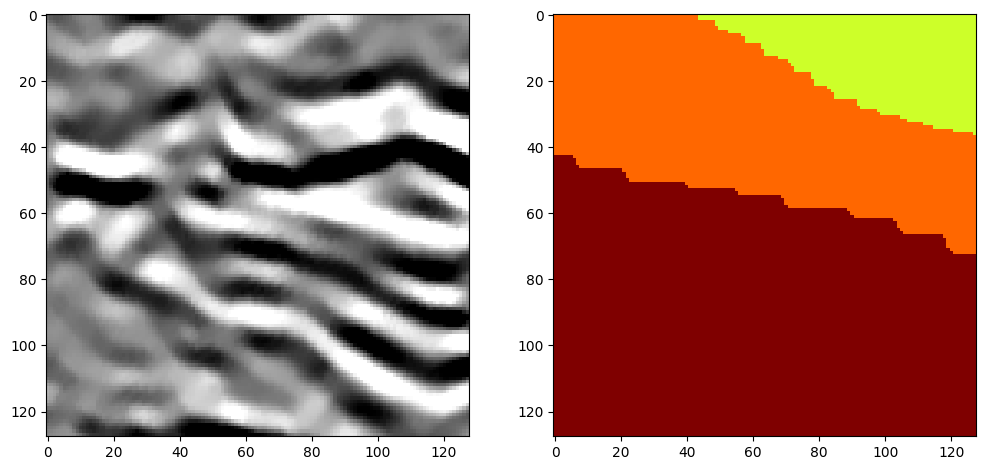

[3 4 5]


In [16]:
image_number = random.randint(0,len(X_train)-1)
print(image_number)
plt.figure(figsize=(12, 6))
plt.subplot(121)
#plt.imshow(X_train[image_number], cmap='gray')
plt.imshow(X_train[image_number,0,:,:], cmap='gray',vmin=0, vmax=1.0)
plt.subplot(122)
#plt.imshow(y_train[image_number], cmap='gray')
plt.imshow(y_train[image_number,0,:,:], cmap='jet',vmin=0, vmax=n_classes-1)
plt.show()

print(np.unique(y_train[image_number]))

Validation

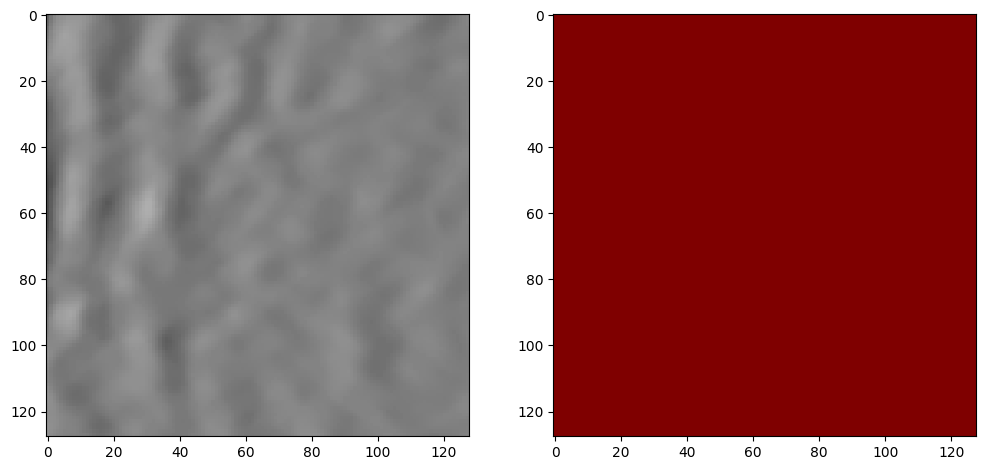

[5]


In [17]:
image_number = random.randint(0,len(X_val)-1)
plt.figure(figsize=(12, 6))
plt.subplot(121)
#plt.imshow(X_val[image_number], cmap='gray')
plt.imshow(X_val[image_number,:,:,0], cmap='gray',vmin=-0, vmax=1.0)
plt.subplot(122)
#plt.imshow(y_val[image_number], cmap='gray')
plt.imshow(y_val[image_number,:,:,0], cmap='jet',vmin=0, vmax=n_classes-1)
plt.show()
print(np.unique(y_val[image_number]))

Test

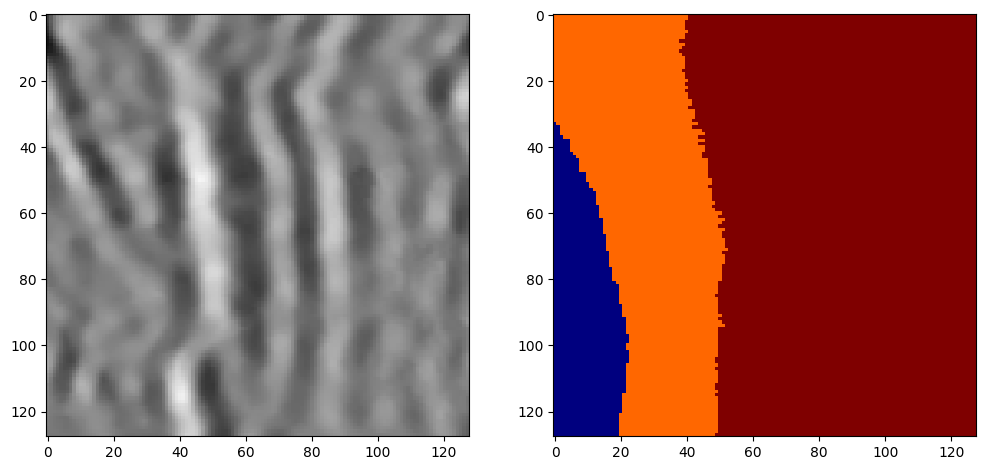

[0 4 5]


In [18]:
image_number = random.randint(0,len(X_test)-1)
plt.figure(figsize=(12, 6))
plt.subplot(121)
#plt.imshow(X_test[image_number], cmap='gray')
plt.imshow(X_test[image_number,:,:,0], cmap='gray',vmin=0, vmax=1.0)
plt.subplot(122)
#plt.imshow(y_test[image_number], cmap='gray')
plt.imshow(y_test[image_number,:,:,0], cmap='jet',vmin=0, vmax=n_classes-1)
plt.show()
print(np.unique(y_test[image_number]))

# Imagens para tiles 

In [19]:
def check_positve3D(X_train,y_train):
    global include_neg_tile
    list_images = []
    list_masks = []

    for i in range(X_train.shape[0]):   #range(img_array.shape[0]): 
        list_images.append(X_train[i])
        list_masks.append(y_train[i])
                
        
    list_images = np.array(list_images, dtype = np.single)
    list_masks = np.array(list_masks, dtype = np.single)
    print(list_images.shape)
    print(list_masks.shape)
    return list_images, list_masks


# Salvar tiles numa pasta

In [20]:

def save_tiles_2(list_images, path_save, prefix='', change_order=False):
    cont = 0
    for i in range(list_images.shape[0]):
        # Adicionamos o prefixo ao nome do arquivo
        filename = os.path.join(path_save, f"{prefix}{str(cont).zfill(4)}.dat")
        block = list_images[i]
        if change_order:
            block = np.transpose(block, (1,0,2))
            
        block.tofile(filename)
        cont += 1
        
def setFolder(path):
    if os.path.exists(path):
        shutil.rmtree(path)
    os.makedirs(path)

img_path  = '../target/images/'
mask_path = '../target/masks/'

setFolder(img_path)
setFolder(mask_path)

print("Salvando tiles de TREINO...")
list_images, list_masks = check_positve3D(X_train, y_train)
save_tiles_2(list_images, img_path, prefix='train_', change_order=change_order)
save_tiles_2(list_masks, mask_path, prefix='train_', change_order=change_order)

print("Salvando tiles de VALIDAÇÃO...")
list_images, list_masks = check_positve3D(X_val, y_val)
save_tiles_2(list_images, img_path, prefix='val_', change_order=change_order)
save_tiles_2(list_masks, mask_path, prefix='val_', change_order=change_order)

print("Salvando tiles de TESTE...")
list_images, list_masks = check_positve3D(X_test, y_test)
save_tiles_2(list_images, img_path, prefix='test_', change_order=change_order)
save_tiles_2(list_masks, mask_path, prefix='test_', change_order=change_order)

Salvando tiles de TREINO...
(595, 128, 128, 128)
(595, 128, 128, 128)
Salvando tiles de VALIDAÇÃO...
(85, 128, 128, 128)
(85, 128, 128, 128)
Salvando tiles de TESTE...
(85, 128, 128, 128)
(85, 128, 128, 128)
